# cen_dna-dataset


In [ ]:
# 挂载云盘
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Tue Oct  7 12:59:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 安装必要的工具和库
!apt-get update
!apt-get install -y bedtools
!pip install biopython pyfaidx

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
# 导入库
import pandas as pd
import numpy as np
import subprocess
import random
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils import gc_fraction

print("所有必要的库已成功安装和导入")

所有必要的库已成功安装和导入


In [ ]:
# 设置文件路径
bed_file_path = "/content/drive/MyDrive/cen_dna/hg38-centromeres-BED"
fasta_file_path = "/content/drive/MyDrive/cen_dna/hg38.fa"

print(f"BED文件路径: {bed_file_path}")
print(f"FASTA文件路径: {fasta_file_path}")

# 检查文件是否存在
import os
if os.path.exists(bed_file_path):
    print("BED文件存在")
else:
    print("BED文件不存在，请检查路径")

if os.path.exists(fasta_file_path):
    print("FASTA文件存在")
else:
    print("FASTA文件不存在，请检查路径")

BED文件路径: /content/drive/MyDrive/cen_dna/hg38-centromeres-BED
FASTA文件路径: /content/drive/MyDrive/cen_dna/hg38.fa
BED文件存在
FASTA文件存在


In [ ]:
# 读取着丝粒BED文件
def read_centromere_bed(bed_file):
    """读取着丝粒BED文件"""
    centromeres = []
    with open(bed_file, 'r') as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    chrom, start, end = parts[0], int(parts[1]), int(parts[2])
                    centromeres.append((chrom, start, end))
    return centromeres

centromere_regions = read_centromere_bed(bed_file_path)
print(f"找到 {len(centromere_regions)} 个着丝粒区域")
for i, (chrom, start, end) in enumerate(centromere_regions):
    print(f"{chrom}:{start}-{end} (长度: {end-start:,} bp)")

找到 109 个着丝粒区域
chr1:122503247-124785432 (长度: 2,282,185 bp)
chr1:122026459-122224535 (长度: 198,076 bp)
chr1:122224635-122503147 (长度: 278,512 bp)
chr1:124849229-124932724 (长度: 83,495 bp)
chr1:124785532-124849129 (长度: 63,597 bp)
chr2:92188145-94090557 (长度: 1,902,412 bp)
chr3:91553419-93655574 (长度: 2,102,155 bp)
chr3:90772458-91233586 (长度: 461,128 bp)
chr3:91233686-91247622 (长度: 13,936 bp)
chr4:49712061-51743951 (长度: 2,031,890 bp)
chr5:47153439-47296069 (长度: 142,630 bp)
chr5:47309184-49591369 (长度: 2,282,185 bp)
chr5:46485900-46569062 (长度: 83,162 bp)
chr5:46569162-46796725 (长度: 227,563 bp)
chr5:46796825-47061288 (长度: 264,463 bp)
chr5:49667531-49721203 (长度: 53,672 bp)
chr5:49721303-50059807 (长度: 338,504 bp)
chr5:47106994-47153339 (长度: 46,345 bp)
chr6:58553888-59829934 (长度: 1,276,046 bp)
chr7:58169653-60828234 (长度: 2,658,581 bp)
chr7:61377788-61528020 (长度: 150,232 bp)
chr8:44033744-45877265 (长度: 1,843,521 bp)
chr9:43389635-45518558 (长度: 2,128,923 bp)
chrX:58605579-62412542 (长度: 3,806,963 bp)
ch

In [ ]:
# 创建着丝粒区域的BED文件（在本地目录）
centromere_bed = 'centromeres_regions.bed'
with open(centromere_bed, 'w') as f:
    for chrom, start, end in centromere_regions:
        f.write(f"{chrom}\t{start}\t{end}\n")

print("着丝粒区域BED文件已创建")

着丝粒区域BED文件已创建


In [ ]:
# 使用bedtools提取着丝粒序列
def extract_sequences(fasta_file, bed_file, output_file):
    """使用bedtools提取指定区域的序列"""
    cmd = f"bedtools getfasta -fi {fasta_file} -bed {bed_file} -fo {output_file}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"错误: {result.stderr}")
    return result.returncode == 0

# 提取着丝粒序列
centromere_fasta = 'centromere_sequences.fa'
if extract_sequences(fasta_file_path, centromere_bed, centromere_fasta):
    print("着丝粒序列提取成功")
else:
    print("着丝粒序列提取失败")

着丝粒序列提取成功


In [ ]:
# 读取FASTA文件并解析序列
def read_fasta(filename):
    """读取FASTA文件"""
    sequences = {}
    current_header = None
    current_sequence = []

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_header is not None:
                    sequences[current_header] = ''.join(current_sequence)
                current_header = line[1:]
                current_sequence = []
            else:
                current_sequence.append(line)

        if current_header is not None:
            sequences[current_header] = ''.join(current_sequence)

    return sequences

# 读取着丝粒序列
centromere_sequences = read_fasta(centromere_fasta)
print(f"提取到 {len(centromere_sequences)} 个着丝粒序列")

提取到 109 个着丝粒序列


In [ ]:
# 生成大量非着丝粒序列
def generate_non_centromere_regions(centromere_regions, target_count, seq_length=1000):
    """生成大量非着丝粒区域"""
    print(f"生成非着丝粒序列，目标数量: {target_count}")

    # 染色体大小信息（hg38）
    chromosome_sizes = {
        'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
        'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
        'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
        'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
        'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
        'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
        'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
        'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415
    }

    non_centromere_regions = []
    centromere_dict = {chrom: (start, end) for chrom, start, end in centromere_regions}

    attempts = 0
    max_attempts = target_count * 20

    while len(non_centromere_regions) < target_count and attempts < max_attempts:
        attempts += 1
        chrom = random.choice(list(chromosome_sizes.keys()))
        chrom_size = chromosome_sizes[chrom]

        # 确保序列在染色体范围内
        if chrom_size <= seq_length:
            continue

        start = random.randint(0, chrom_size - seq_length)
        end = start + seq_length

        # 检查是否与着丝粒区域重叠
        if chrom in centromere_dict:
            cent_start, cent_end = centromere_dict[chrom]
            if not (end <= cent_start or start >= cent_end):
                continue  # 重叠，跳过

        non_centromere_regions.append((chrom, start, end))

        if len(non_centromere_regions) % 10000 == 0:
            print(f"已生成 {len(non_centromere_regions)} 个非着丝粒区域")

    print(f"成功生成 {len(non_centromere_regions)} 个非着丝粒区域")
    return non_centromere_regions

# 计算需要生成的非着丝粒序列数量
target_negative_count = len(centromere_sequences) * 600  # 生成600倍于着丝粒序列的数量
print(f"目标非着丝粒序列数量: {target_negative_count}")

# 生成非着丝粒区域
non_centromere_regions = generate_non_centromere_regions(
    centromere_regions,
    target_count=target_negative_count,
    seq_length=1000
)

目标非着丝粒序列数量: 65400
生成非着丝粒序列，目标数量: 65400
已生成 10000 个非着丝粒区域
已生成 20000 个非着丝粒区域
已生成 30000 个非着丝粒区域
已生成 40000 个非着丝粒区域
已生成 50000 个非着丝粒区域
已生成 60000 个非着丝粒区域
成功生成 65400 个非着丝粒区域


In [ ]:
# 创建非着丝粒BED文件并提取序列
non_centromere_bed = 'non_centromeres.bed'
with open(non_centromere_bed, 'w') as f:
    for chrom, start, end in non_centromere_regions:
        f.write(f"{chrom}\t{start}\t{end}\n")

# 提取非着丝粒序列
non_centromere_fasta = 'non_centromere_sequences.fa'
if extract_sequences(fasta_file_path, non_centromere_bed, non_centromere_fasta):
    print("非着丝粒序列提取成功")
else:
    print("非着丝粒序列提取失败")

# 读取非着丝粒序列
non_centromere_sequences = read_fasta(non_centromere_fasta)
print(f"提取到 {len(non_centromere_sequences)} 个非着丝粒序列")

非着丝粒序列提取成功
提取到 65398 个非着丝粒序列


In [ ]:
# 如果数据集仍然不平衡，进行最终平衡
def balance_dataset(df, target_ratio=1):
    """平衡数据集"""
    positive = df[df['label'] == 1]
    negative = df[df['label'] == 0]

    print(f"平衡前 - 正样本: {len(positive)}, 负样本: {len(negative)}")

    # 确定目标数量
    if len(positive) > len(negative):
        # 正样本多，下采样正样本
        target_count = min(len(positive), len(negative) * target_ratio)
        positive_balanced = positive.sample(n=int(target_count), random_state=42)
        balanced_df = pd.concat([positive_balanced, negative], axis=0)
    else:
        # 负样本多，下采样负样本
        target_count = min(len(negative), len(positive) * target_ratio)
        negative_balanced = negative.sample(n=int(target_count), random_state=42)
        balanced_df = pd.concat([positive, negative_balanced], axis=0)

    # 打乱顺序
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"平衡后 - 正样本: {len(balanced_df[balanced_df['label'] == 1])}, 负样本: {len(balanced_df[balanced_df['label'] == 0])}")

    return balanced_df

# 平衡数据集
df_balanced = balance_dataset(df, target_ratio=1)

print(f"最终数据集大小: {len(df_balanced)}")
print(f"着丝粒序列: {len(df_balanced[df_balanced['label'] == 1])}")
print(f"非着丝粒序列: {len(df_balanced[df_balanced['label'] == 0])}")
print(f"平衡比例: {len(df_balanced[df_balanced['label'] == 1]) / len(df_balanced[df_balanced['label'] == 0]):.2f}:1")

平衡前 - 正样本: 59359, 负样本: 60766
平衡后 - 正样本: 59359, 负样本: 59359
最终数据集大小: 118718
着丝粒序列: 59359
非着丝粒序列: 59359
平衡比例: 1.00:1


In [ ]:
# 保存数据集到Google Drive
def save_dataset(df, output_file):
    """保存数据集为CSV文件"""
    # 只保存序列和标签
    save_df = df[['sequence', 'label']].copy()
    save_df.to_csv(output_file, index=False)
    return save_df

# 保存完整平衡数据集
balanced_dataset_file = '/content/drive/MyDrive/cen_dna/centromere_dataset_balanced.csv'
saved_df = save_dataset(df_balanced, balanced_dataset_file)
print(f"平衡数据集已保存到: {balanced_dataset_file}")

# 保存不含N的清洁数据集
def filter_n_sequences(df):
    """过滤掉含有N的序列"""
    df_clean = df[~df['sequence'].str.contains('N', case=False, na=False)].copy()
    return df_clean

df_clean = filter_n_sequences(df_balanced)
clean_dataset_file = '/content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv'
df_clean.to_csv(clean_dataset_file, index=False)
print(f"清洁平衡数据集已保存到: {clean_dataset_file}")
print(f"清洁数据集大小: {len(df_clean)} (移除了 {len(df_balanced) - len(df_clean)} 条含N的序列)")

# 显示数据集前几行
print("\n数据集前5行:")
print(saved_df.head())

平衡数据集已保存到: /content/drive/MyDrive/cen_dna/centromere_dataset_balanced.csv
清洁平衡数据集已保存到: /content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv
清洁数据集大小: 118717 (移除了 1 条含N的序列)

数据集前5行:
                                            sequence  label
0  CAGATCACAATTTCTATTTTTTTCAAATACTATAGCTTTATTATTT...      0
1  TGCTTGGCATTAAAAATTATAAAATCATTAAATTGTTTATTACAGT...      0
2  AAACAGATGGGCAAGTCTTCTACCCCCACTTCTGAAGCTGAGAGGG...      0
3  aggcctatggtgaaaaaggaaatatcttctcctgaaaactagacag...      1
4  tcacagagttgaacattccttttgatagagcagttttgaaactctc...      1


In [ ]:
# 保存序列文件到Google Drive
import shutil
shutil.copy(centromere_fasta, '/content/drive/MyDrive/cen_dna/')
shutil.copy(non_centromere_fasta, '/content/drive/MyDrive/cen_dna/')
print("序列文件也已保存到Google Drive")

# 最终统计
print("\n=== 数据准备完成 ===")
print(f"总序列数: {len(df_balanced)}")
print(f"着丝粒序列: {len(df_balanced[df_balanced['label'] == 1])}")
print(f"非着丝粒序列: {len(df_balanced[df_balanced['label'] == 0])}")
print(f"平衡比例: 1:{len(df_balanced[df_balanced['label'] == 0]) / len(df_balanced[df_balanced['label'] == 1]):.2f}")
print(f"序列长度: 1000 bp")

print("\n生成的文件:")
print(f"1. {balanced_dataset_file} - 完整平衡数据集")
print(f"2. {clean_dataset_file} - 清洁平衡数据集（不含N）")
print(f"3. /content/drive/MyDrive/cen_dna/centromere_sequences.fa - 着丝粒序列")
print(f"4. /content/drive/MyDrive/cen_dna/non_centromere_sequences.fa - 非着丝粒序列")

序列文件也已保存到Google Drive

=== 数据准备完成 ===
总序列数: 118718
着丝粒序列: 59359
非着丝粒序列: 59359
平衡比例: 1:1.00
序列长度: 1000 bp

生成的文件:
1. /content/drive/MyDrive/cen_dna/centromere_dataset_balanced.csv - 完整平衡数据集
2. /content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv - 清洁平衡数据集（不含N）
3. /content/drive/MyDrive/cen_dna/centromere_sequences.fa - 着丝粒序列
4. /content/drive/MyDrive/cen_dna/non_centromere_sequences.fa - 非着丝粒序列


# data cleaning


In [ ]:
import pandas as pd
from collections import Counter
from tqdm import tqdm
import numpy as np

INPUT_FILE = '/content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv'
OUTPUT_FILE = '/content/drive/MyDrive/cen_dna/centromere_label1_cleaned_final.csv'
REPORT_FILE = '/content/drive/MyDrive/cen_dna/centromere_label1_cleaning_report.txt'
SEQ_LENGTH = 1000
MAX_N_PERCENT = 0.05

def load_dataset(file):
    return pd.read_csv(file)

def quality_filter(df, seq_length=1000, max_n_percent=0.05):
    before = len(df)
    df = df[df['sequence'].str.len() == seq_length] #只保留长度等于seq_length（默认1000bp）的序列。
    n_count = df['sequence'].apply(lambda x: x.upper().count('N')) #用lambda函数对每条序列x转大写后统计“N”的数量。
    df = df[n_count <= seq_length * max_n_percent] #只保留“N”个数小于等于最大允许比例（比如5%）的序列
    after = len(df)
    return df, before, after #返回过滤后的df、过滤前数量和过滤后数量

def deduplicate_exact(df): #记录去重前的数据条数
    before = len(df)
    df = df.drop_duplicates(subset=['sequence']) #精确去重：同样的序列只保留一条
    after = len(df)
    return df, before, after

def deduplicate_kmer(df, k=15, threshold=0.8): #如果两个序列相似度大于等于threshold，则后一个序列标记为不要
    def kmer_set(seq, k):
        return set(seq[i:i + k] for i in range(len(seq) - k + 1)) #获取序列所有长度为k的k-mer集合
    seq_kmers = [kmer_set(seq, k) for seq in tqdm(df['sequence'], desc="计算k-mer集合")] #对所有序列生成k-mer集合，进度条显示
    keep = np.ones(len(df), dtype=bool) #创建布尔数组keep，标记哪些序列保留（初始全为True）
    for i in tqdm(range(len(seq_kmers)), desc="比对k-mer相似性"): #使用tqdm创建进度条，遍历所有序列的索引
        if not keep[i]:
            continue
        for j in range(i + 1, len(seq_kmers)): #避免重复比较（i<j）和自比较
            if not keep[j]:
                continue
            set_i = seq_kmers[i]
            set_j = seq_kmers[j]
            intersection = len(set_i & set_j)
            union = len(set_i | set_j)
            if union == 0:
                continue
            jaccard = intersection / union
            if jaccard >= threshold:
                keep[j] = False
    df_dedup = df[keep].reset_index(drop=True)
    return df_dedup, sum(~keep)

def composition_analysis(df):
    stats = {}
    seqs = df['sequence']
    total = len(seqs)
    lens = seqs.str.len()
    stats['total_sequences'] = total
    stats['min_length'] = lens.min()
    stats['max_length'] = lens.max()
    stats['mean_length'] = lens.mean()
    gc = seqs.apply(lambda x: x.upper().count('G') + x.upper().count('C'))
    n = seqs.apply(lambda x: x.upper().count('N'))
    stats['GC_mean'] = (gc / lens).mean()
    stats['N_mean'] = (n / lens).mean()
    stats['A_mean'] = (seqs.apply(lambda x: x.upper().count('A')) / lens).mean()
    stats['T_mean'] = (seqs.apply(lambda x: x.upper().count('T')) / lens).mean()
    stats['G_mean'] = (seqs.apply(lambda x: x.upper().count('G')) / lens).mean()
    stats['C_mean'] = (seqs.apply(lambda x: x.upper().count('C')) / lens).mean()
    return stats

def write_report(before_stats, after_stats, quality_counts, dedup_counts, kmer_dedup_removed):
    lines = []
    lines.append("=== 着丝粒(label==1)清洗前后质量报告 ===\n")
    lines.append("【清洗前】")
    for k, v in before_stats.items():
        lines.append(f"{k}: {v}")
    lines.append("\n【质量过滤后】")
    lines.append(f"剩余序列数: {quality_counts[2]} (去除 {quality_counts[0] - quality_counts[2]})")
    lines.append("\n【精确去重后】")
    lines.append(f"剩余序列数: {dedup_counts[2]} (去除 {dedup_counts[0] - dedup_counts[2]})")
    lines.append("\n【k-mer去重后】")
    lines.append(f"剩余序列数: {after_stats['total_sequences']} (去除 {kmer_dedup_removed})")
    lines.append("\n【清洗后】")
    for k, v in after_stats.items():
        lines.append(f"{k}: {v}")
    with open(REPORT_FILE, "w", encoding='utf-8') as f:
        f.write('\n'.join(lines))
    print('\n'.join(lines))

# 主流程
df = load_dataset(INPUT_FILE)

# 只选取label为1的着丝粒序列
df_cen = df[df['label'] == 1].copy()

before_stats = composition_analysis(df_cen)

# 质量过滤
df1, q_before, q_after = quality_filter(df_cen, seq_length=SEQ_LENGTH, max_n_percent=MAX_N_PERCENT)

# 精确去重
df2, d_before, d_after = deduplicate_exact(df1)

# k-mer去重
df3, kmer_removed = deduplicate_kmer(df2, k=15, threshold=0.95)

after_stats = composition_analysis(df3)

# 保存最终数据集
df3.to_csv(OUTPUT_FILE, index=False)

# 输出并保存报告
write_report(before_stats, after_stats, (q_before, None, q_after), (d_before, None, d_after), kmer_removed)

比对k-mer相似性:   1%|▏         | 640/48275 [54:18<64:14:35,  4.86s/it]

# clean+Nucleotide Transformer

In [ ]:
# 安装必要的库
!pip install transformers torch scikit-learn matplotlib seaborn pandas numpy tqdm

# 导入库
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import os

print("所有库已成功导入")

所有库已成功导入


In [ ]:
# 加载清洁平衡数据集
data_path = "/content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv"
df = pd.read_csv(data_path)

print("数据集信息:")
print(f"总序列数: {len(df)}")
print(f"着丝粒序列: {len(df[df['label']==1])}")
print(f"非着丝粒序列: {len(df[df['label']==0])}")
print(f"序列长度: {len(df.iloc[0]['sequence'])} bp")

# 检查数据质量
print("\n数据质量检查:")
print(f"包含'N'的序列数量: {df['sequence'].str.contains('N', case=False, na=False).sum()}")
print(f"序列长度一致性: {df['sequence'].str.len().nunique()} 种不同长度")

# 显示前几行数据
print("\n数据预览:")
print(df.head())

数据集信息:
总序列数: 118717
着丝粒序列: 59359
非着丝粒序列: 59358
序列长度: 1000 bp

数据质量检查:
包含'N'的序列数量: 0
序列长度一致性: 1 种不同长度

数据预览:
                                            sequence  label  \
0  CAGATCACAATTTCTATTTTTTTCAAATACTATAGCTTTATTATTT...      0   
1  TGCTTGGCATTAAAAATTATAAAATCATTAAATTGTTTATTACAGT...      0   
2  AAACAGATGGGCAAGTCTTCTACCCCCACTTCTGAAGCTGAGAGGG...      0   
3  aggcctatggtgaaaaaggaaatatcttctcctgaaaactagacag...      1   
4  tcacagagttgaacattccttttgatagagcagttttgaaactctc...      1   

                     source   position  
0  chrX:146452114-146453114  146452114  
1   chr21:37901846-37902846   37901846  
2    chrX:69144838-69145838   69144838  
3    chr2:92188145-94090557     349000  
4  chr1:122224635-122503147     184000  


In [ ]:
# 定义Nucleotide Transformer分析器
class CentromereAnalyzer:
    def __init__(self, model_name="InstaDeepAI/nucleotide-transformer-500m-1000g"):
        """初始化Nucleotide Transformer模型"""
        print(f"加载模型: {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"使用设备: {self.device}")
        self.model.to(self.device)
        self.model.eval()

    def get_sequence_embeddings(self, sequences, batch_size=8, show_progress=True):
        """获取序列嵌入向量"""
        embeddings = []

        if show_progress:
            pbar = tqdm(total=len(sequences), desc="获取序列嵌入")

        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i:i+batch_size]

            # 编码序列
            inputs = self.tokenizer(
                batch_seqs,
                padding=True,
                truncation=True,
                max_length=1000,
                return_tensors="pt"
            ).to(self.device)

            # 获取嵌入
            with torch.no_grad():
                outputs = self.model(**inputs)
                # 使用[CLS] token的嵌入作为序列表示
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(batch_embeddings)

            if show_progress:
                pbar.update(len(batch_seqs))

        if show_progress:
            pbar.close()

        return np.vstack(embeddings)

    def analyze_centromere_features(self, sequences, labels, sample_size=None):
        """分析着丝粒序列特征"""
        if sample_size and sample_size < len(sequences):
            print(f"使用子集进行分析: {sample_size} 条序列")
            indices = np.random.choice(len(sequences), sample_size, replace=False)
            sequences = [sequences[i] for i in indices]
            labels = labels[indices]
        else:
            print(f"使用全部数据进行分析: {len(sequences)} 条序列")

        print("获取序列嵌入...")
        embeddings = self.get_sequence_embeddings(sequences)

        print("降维可视化...")
        # PCA降维
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)

        # t-SNE降维
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        embeddings_tsne = tsne.fit_transform(embeddings)

        # 创建可视化
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # PCA图
        scatter1 = ax1.scatter(embeddings_2d[labels==0, 0], embeddings_2d[labels==0, 1],
                              alpha=0.6, label='非着丝粒', s=10, c='red')
        scatter2 = ax1.scatter(embeddings_2d[labels==1, 0], embeddings_2d[labels==1, 1],
                              alpha=0.6, label='着丝粒', s=10, c='blue')
        ax1.set_title('PCA - 序列嵌入空间分布')
        ax1.legend()
        ax1.set_xlabel(f'主成分1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax1.set_ylabel(f'主成分2 ({pca.explained_variance_ratio_[1]:.2%})')

        # t-SNE图
        scatter3 = ax2.scatter(embeddings_tsne[labels==0, 0], embeddings_tsne[labels==0, 1],
                              alpha=0.6, label='非着丝粒', s=10, c='red')
        scatter4 = ax2.scatter(embeddings_tsne[labels==1, 0], embeddings_tsne[labels==1, 1],
                              alpha=0.6, label='着丝粒', s=10, c='blue')
        ax2.set_title('t-SNE - 序列嵌入空间分布')
        ax2.legend()
        ax2.set_xlabel('t-SNE 1')
        ax2.set_ylabel('t-SNE 2')

        plt.tight_layout()
        plt.show()

        # 计算类间距离
        centromere_embeddings = embeddings[labels == 1]
        non_centromere_embeddings = embeddings[labels == 0]

        centromere_center = np.mean(centromere_embeddings, axis=0)
        non_centromere_center = np.mean(non_centromere_embeddings, axis=0)

        class_distance = np.linalg.norm(centromere_center - non_centromere_center)
        print(f"着丝粒与非着丝粒序列在嵌入空间的平均距离: {class_distance:.4f}")

        return {
            'embeddings': embeddings,
            'pca': embeddings_2d,
            'tsne': embeddings_tsne,
            'pca_model': pca,
            'sequences': sequences,
            'labels': labels
        }

# 初始化分析器
analyzer = CentromereAnalyzer()

加载模型: InstaDeepAI/nucleotide-transformer-500m-1000g


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-1000g and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


使用设备: cpu


In [ ]:
# 准备数据
sequences = df['sequence'].tolist()
labels = df['label'].values

print(f"准备分析 {len(sequences)} 条序列")
print(f"着丝粒: {np.sum(labels == 1)} 条")
print(f"非着丝粒: {np.sum(labels == 0)} 条")

准备分析 118717 条序列
着丝粒: 59359 条
非着丝粒: 59358 条


开始分析着丝粒序列特征...
使用子集进行分析: 2000 条序列
获取序列嵌入...



获取序列嵌入: 100%|██████████| 2000/2000 [1:16:11<00:00,  2.29s/it]


降维可视化...


/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 23884 (\N{CJK UNIFIED IDEOGRAPH-5D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2328976020.py:92: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missi

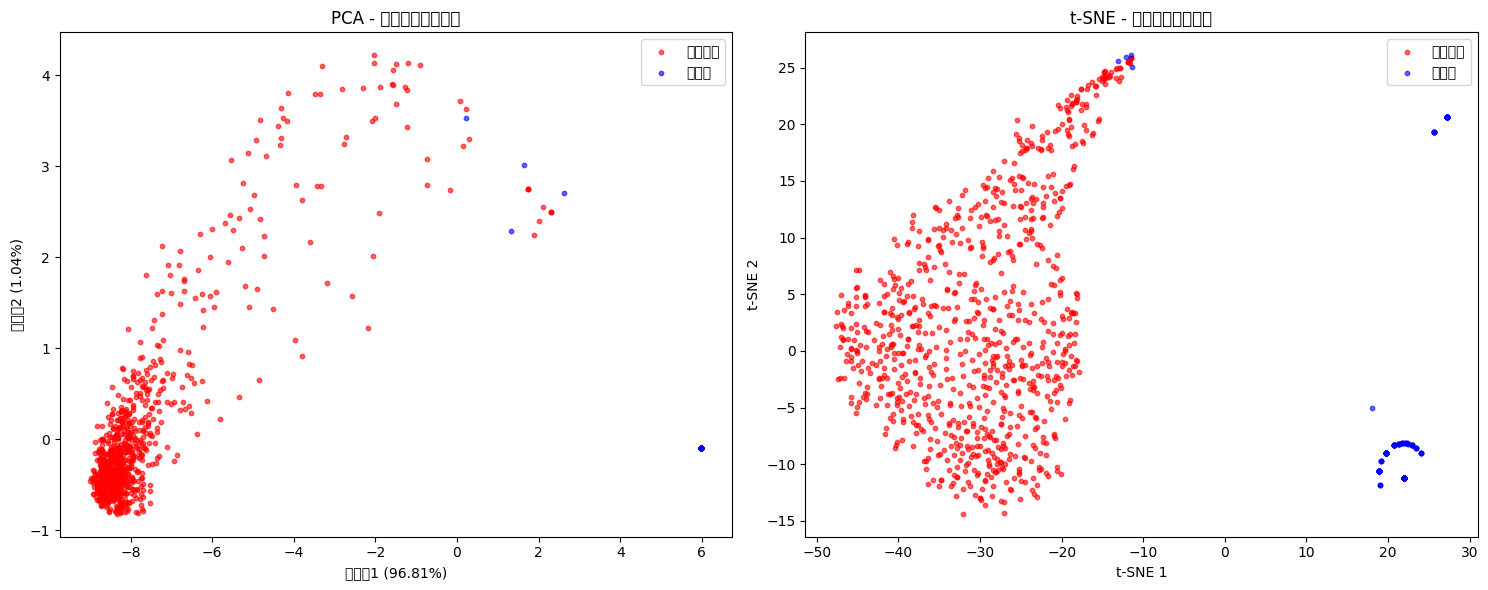

着丝粒与非着丝粒序列在嵌入空间的平均距离: 11.7071
嵌入向量已保存到: /content/drive/MyDrive/cen_dna/sequence_embeddings.npy


In [ ]:
# 运行分析（使用子集进行快速分析）
print("开始分析着丝粒序列特征...")
sample_size = 2000  # 使用2000条序列进行快速分析，可以调整

results = analyzer.analyze_centromere_features(sequences, labels, sample_size=sample_size)

# 保存嵌入结果
embeddings_path = '/content/drive/MyDrive/cen_dna/sequence_embeddings.npy'
np.save(embeddings_path, results['embeddings'])
print(f"嵌入向量已保存到: {embeddings_path}")

评估聚类质量...


/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 23884 (\N{CJK UNIFIED IDEOGRAPH-5D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1316860250.py:34: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missi

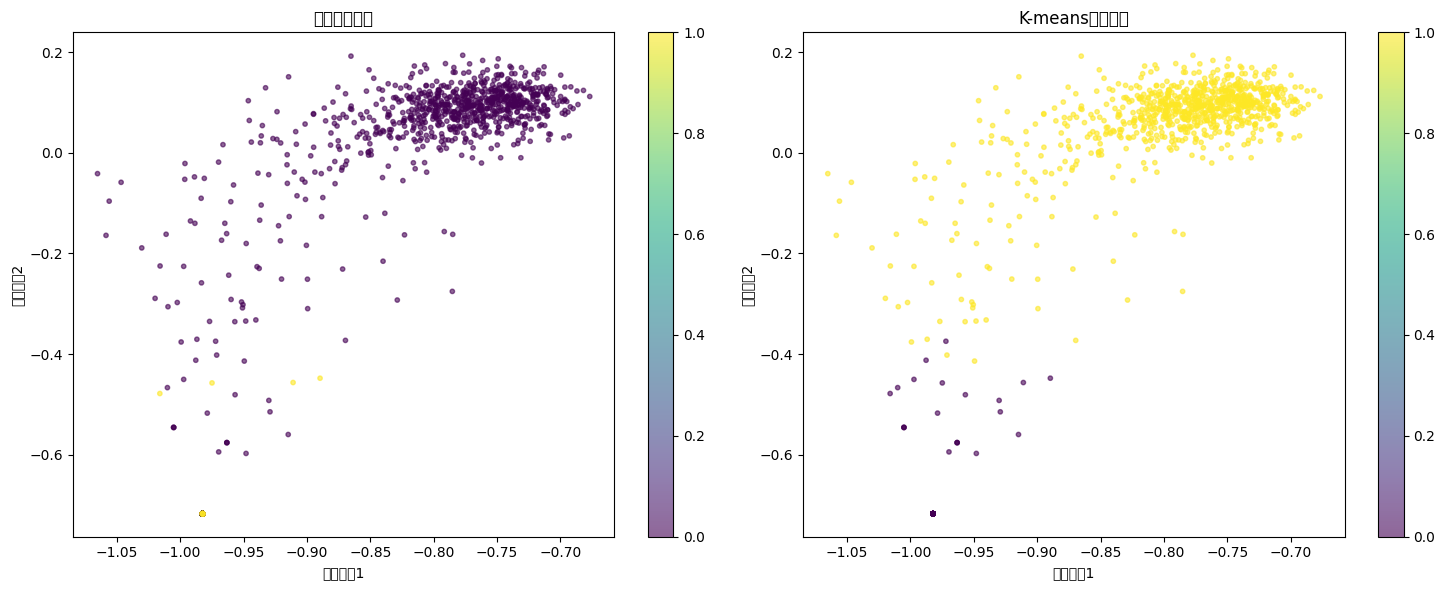

轮廓系数: 0.8986 (越高越好)
调整兰德指数: 0.7021 (越高越好，1表示完美匹配)


In [ ]:
# 深入分析：聚类质量评估
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

def evaluate_clustering(embeddings, true_labels):
    """评估聚类质量"""
    # K-means聚类
    kmeans = KMeans(n_clusters=2, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # 计算聚类指标
    silhouette = silhouette_score(embeddings, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)

    # 可视化聚类结果
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 真实标签
    scatter1 = ax1.scatter(embeddings[:, 0], embeddings[:, 1],
                          c=true_labels, cmap='viridis', alpha=0.6, s=10)
    ax1.set_title('真实标签分布')
    ax1.set_xlabel('嵌入维度1')
    ax1.set_ylabel('嵌入维度2')
    plt.colorbar(scatter1, ax=ax1)

    # 聚类结果
    scatter2 = ax2.scatter(embeddings[:, 0], embeddings[:, 1],
                          c=cluster_labels, cmap='viridis', alpha=0.6, s=10)
    ax2.set_title('K-means聚类结果')
    ax2.set_xlabel('嵌入维度1')
    ax2.set_ylabel('嵌入维度2')
    plt.colorbar(scatter2, ax=ax2)

    plt.tight_layout()
    plt.show()

    print(f"轮廓系数: {silhouette:.4f} (越高越好)")
    print(f"调整兰德指数: {ari:.4f} (越高越好，1表示完美匹配)")

    return cluster_labels, silhouette, ari

print("评估聚类质量...")
cluster_labels, silhouette, ari = evaluate_clustering(results['embeddings'], results['labels'])

分析序列相似性...
序列相似性分析:
着丝粒序列内部平均相似度: 0.9999
非着丝粒序列内部平均相似度: 0.9752
着丝粒与非着丝粒序列间平均相似度: 0.9280


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas

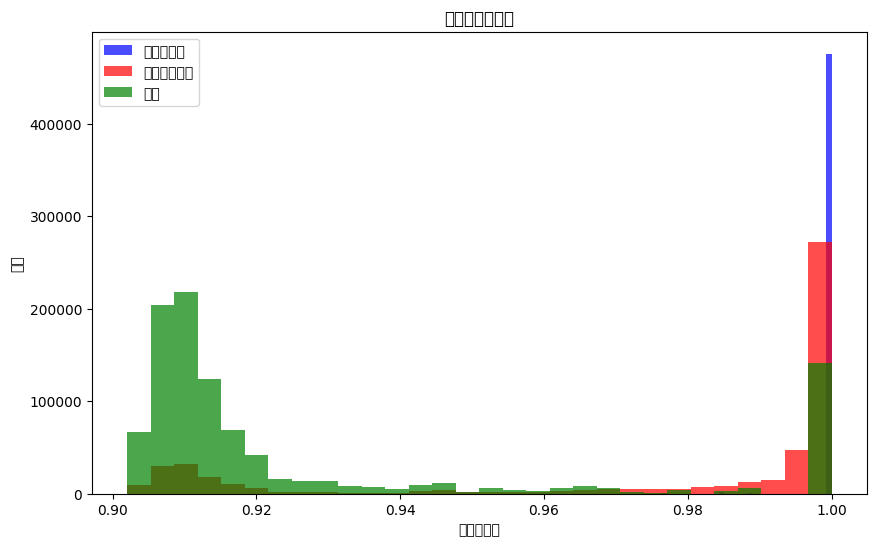

In [ ]:
# 序列相似性分析
def analyze_sequence_similarity(embeddings, labels, sequences, top_k=10):
    """分析序列相似性"""
    from sklearn.metrics.pairwise import cosine_similarity

    # 计算余弦相似度矩阵
    similarity_matrix = cosine_similarity(embeddings)

    # 分析着丝粒序列的内部相似性
    centromere_indices = np.where(labels == 1)[0]
    non_centromere_indices = np.where(labels == 0)[0]

    # 着丝粒序列间平均相似度
    centromere_similarity = similarity_matrix[centromere_indices][:, centromere_indices]
    centromere_avg_similarity = np.mean(centromere_similarity)

    # 非着丝粒序列间平均相似度
    non_centromere_similarity = similarity_matrix[non_centromere_indices][:, non_centromere_indices]
    non_centromere_avg_similarity = np.mean(non_centromere_similarity)

    # 类间平均相似度
    between_similarity = similarity_matrix[centromere_indices][:, non_centromere_indices]
    between_avg_similarity = np.mean(between_similarity)

    print("序列相似性分析:")
    print(f"着丝粒序列内部平均相似度: {centromere_avg_similarity:.4f}")
    print(f"非着丝粒序列内部平均相似度: {non_centromere_avg_similarity:.4f}")
    print(f"着丝粒与非着丝粒序列间平均相似度: {between_avg_similarity:.4f}")

    # 可视化相似度分布
    plt.figure(figsize=(10, 6))

    # 提取上三角矩阵，避免重复计数
    centromere_triu = centromere_similarity[np.triu_indices_from(centromere_similarity, k=1)]
    non_centromere_triu = non_centromere_similarity[np.triu_indices_from(non_centromere_similarity, k=1)]

    plt.hist(centromere_triu, alpha=0.7, bins=30, label='着丝粒内部', color='blue')
    plt.hist(non_centromere_triu, alpha=0.7, bins=30, label='非着丝粒内部', color='red')
    plt.hist(between_similarity.flatten(), alpha=0.7, bins=30, label='类间', color='green')

    plt.title('序列相似度分布')
    plt.xlabel('余弦相似度')
    plt.ylabel('频率')
    plt.legend()
    plt.show()

    return similarity_matrix

print("分析序列相似性...")
similarity_matrix = analyze_sequence_similarity(
    results['embeddings'],
    results['labels'],
    results['sequences']
)

Analyzing feature importance...
Random Forest Classification Accuracy: 0.9183

Classification Report:
                precision    recall  f1-score   support

Non-centromere       1.00      0.84      0.91       306
    Centromere       0.86      1.00      0.92       294

      accuracy                           0.92       600
     macro avg       0.93      0.92      0.92       600
  weighted avg       0.93      0.92      0.92       600



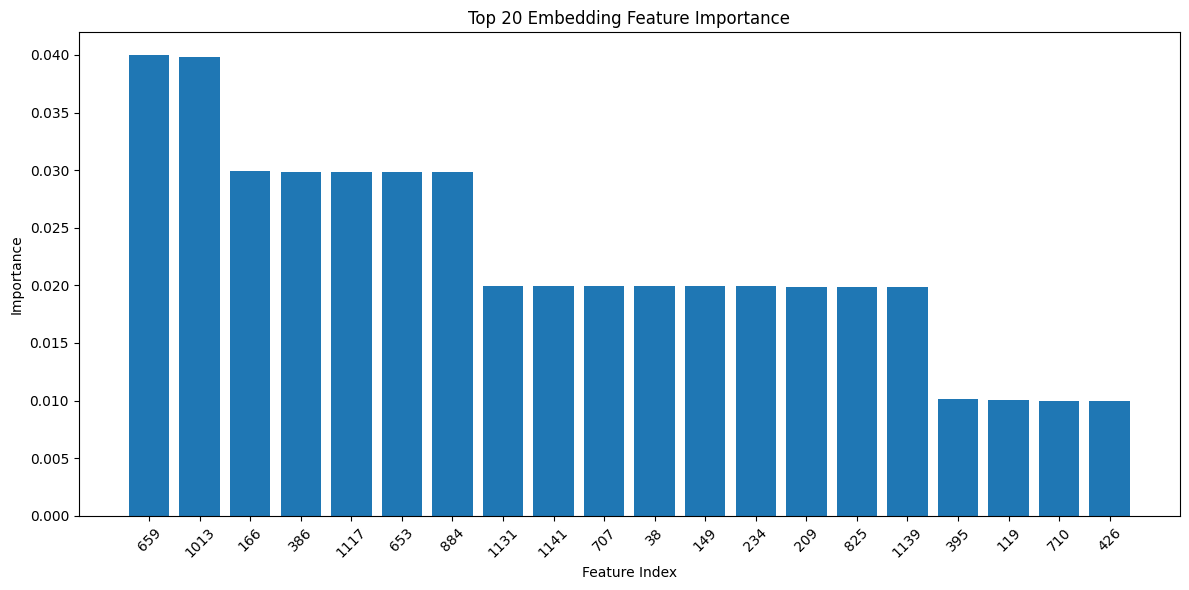

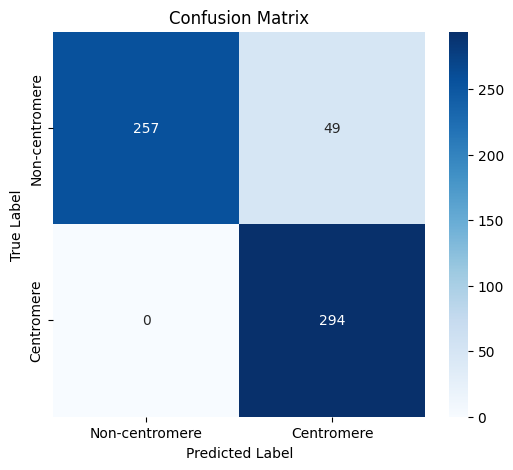

In [ ]:
# Feature Importance Analysis
def analyze_feature_importance(embeddings, labels, top_features=20):
    """Analyze embedding feature importance"""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.3, random_state=42, stratify=labels
    )

    # Train Random Forest classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = rf.predict(X_test)
    accuracy = rf.score(X_test, y_test)

    print(f"Random Forest Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-centromere', 'Centromere']))

    # Feature importance
    feature_importance = rf.feature_importances_
    top_indices = np.argsort(feature_importance)[-top_features:][::-1]

    plt.figure(figsize=(12, 6))
    plt.bar(range(top_features), feature_importance[top_indices])
    plt.title(f'Top {top_features} Embedding Feature Importance')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.xticks(range(top_features), top_indices, rotation=45)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-centromere', 'Centromere'],
                yticklabels=['Non-centromere', 'Centromere'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return rf, accuracy

print("Analyzing feature importance...")
rf_model, accuracy = analyze_feature_importance(results['embeddings'], results['labels'])

In [ ]:
# 保存分析结果
def save_analysis_results(results, df, file_prefix):
    """保存分析结果"""
    # 创建结果数据框
    results_df = pd.DataFrame({
        'sequence': results['sequences'],
        'label': results['labels'],
        'pca_1': results['pca'][:, 0],
        'pca_2': results['pca'][:, 1],
        'tsne_1': results['tsne'][:, 0],
        'tsne_2': results['tsne'][:, 1]
    })

    # 保存结果
    results_path = f'/content/drive/MyDrive/cen_dna/{file_prefix}_analysis_results.csv'
    results_df.to_csv(results_path, index=False)

    # 保存嵌入向量
    embeddings_path = f'/content/drive/MyDrive/cen_dna/{file_prefix}_embeddings.npy'
    np.save(embeddings_path, results['embeddings'])

    print(f"分析结果已保存到: {results_path}")
    print(f"嵌入向量已保存到: {embeddings_path}")

    return results_path, embeddings_path

# 保存当前分析结果
results_path, embeddings_path = save_analysis_results(results, df, "centromere_clean_balanced")

分析结果已保存到: /content/drive/MyDrive/cen_dna/centromere_clean_balanced_analysis_results.csv
嵌入向量已保存到: /content/drive/MyDrive/cen_dna/centromere_clean_balanced_embeddings.npy


In [ ]:
# 生成分析报告
def generate_analysis_report(results, df, sample_size):
    """生成分析报告"""
    print("=" * 60)
    print("               着丝粒序列特征分析报告")
    print("=" * 60)

    print(f"\n数据集信息:")
    print(f"  - 总序列数: {len(df)}")
    print(f"  - 着丝粒序列: {len(df[df['label']==1])}")
    print(f"  - 非着丝粒序列: {len(df[df['label']==0])}")
    print(f"  - 分析样本数: {sample_size}")
    print(f"  - 序列长度: {len(df.iloc[0]['sequence'])} bp")

    print(f"\n分析结果摘要:")
    print(f"  - 使用的模型: Nucleotide Transformer 500M")
    print(f"  - 嵌入维度: {results['embeddings'].shape[1]}")
    print(f"  - PCA解释方差: {results['pca_model'].explained_variance_ratio_.sum():.2%}")

    # 计算一些基本统计
    centromere_embeddings = results['embeddings'][results['labels'] == 1]
    non_centromere_embeddings = results['embeddings'][results['labels'] == 0]

    centromere_center = np.mean(centromere_embeddings, axis=0)
    non_centromere_center = np.mean(non_centromere_embeddings, axis=0)
    class_distance = np.linalg.norm(centromere_center - non_centromere_center)

    print(f"  - 类间距离: {class_distance:.4f}")
    print(f"  - 着丝粒序列嵌入方差: {np.var(centromere_embeddings):.4f}")
    print(f"  - 非着丝粒序列嵌入方差: {np.var(non_centromere_embeddings):.4f}")

    print(f"\n关键发现:")
    if class_distance > 1.0:
        print("  ✓ 着丝粒和非着丝粒序列在嵌入空间中有明显区分")
    else:
        print("  ⚠ 着丝粒和非着丝粒序列在嵌入空间中区分度有限")

    if np.var(centromere_embeddings) < np.var(non_centromere_embeddings):
        print("  ✓ 着丝粒序列比非着丝粒序列更具一致性")
    else:
        print("  ⚠ 着丝粒序列比非着丝粒序列更具多样性")


# 生成报告
generate_analysis_report(results, df, sample_size)

               着丝粒序列特征分析报告

数据集信息:
  - 总序列数: 118717
  - 着丝粒序列: 59359
  - 非着丝粒序列: 59358
  - 分析样本数: 2000
  - 序列长度: 1000 bp

分析结果摘要:
  - 使用的模型: Nucleotide Transformer 500M
  - 嵌入维度: 1280
  - PCA解释方差: 97.85%
  - 类间距离: 11.7071
  - 着丝粒序列嵌入方差: 0.8934
  - 非着丝粒序列嵌入方差: 0.9027

关键发现:
  ✓ 着丝粒和非着丝粒序列在嵌入空间中有明显区分
  ✓ 着丝粒序列比非着丝粒序列更具一致性


In [ ]:
# 首先确保我们有正确的数据变量
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, silhouette_score
from scipy.stats import gaussian_kde

# 检查数据分布
def analyze_data_distribution(results):
    """分析数据分布情况"""
    labels = results['labels']
    embeddings = results['embeddings']

    print("=== 数据分布分析 ===")
    print(f"总样本数: {len(labels)}")
    print(f"着丝粒序列(蓝色): {np.sum(labels == 1)}")
    print(f"非着丝粒序列(红色): {np.sum(labels == 0)}")
    print(f"正负样本比例: {np.sum(labels == 1)}:{np.sum(labels == 0)}")

    # 检查嵌入向量的分布
    centromere_embeddings = embeddings[labels == 1]
    non_centromere_embeddings = embeddings[labels == 0]

    print(f"\n嵌入向量统计:")
    print(f"着丝粒嵌入均值: {np.mean(centromere_embeddings):.4f}")
    print(f"非着丝粒嵌入均值: {np.mean(non_centromere_embeddings):.4f}")
    print(f"着丝粒嵌入方差: {np.var(centromere_embeddings):.4f}")
    print(f"非着丝粒嵌入方差: {np.var(non_centromere_embeddings):.4f}")

    return {
        'centromere_count': np.sum(labels == 1),
        'non_centromere_count': np.sum(labels == 0),
        'ratio': np.sum(labels == 1) / np.sum(labels == 0)
    }

# 分析当前结果的数据分布
distribution = analyze_data_distribution(results)

=== 数据分布分析 ===
总样本数: 2000
着丝粒序列(蓝色): 980
非着丝粒序列(红色): 1020
正负样本比例: 980:1020

嵌入向量统计:
着丝粒嵌入均值: -0.0010
非着丝粒嵌入均值: -0.0011
着丝粒嵌入方差: 0.8934
非着丝粒嵌入方差: 0.9027


生成改进的可视化...


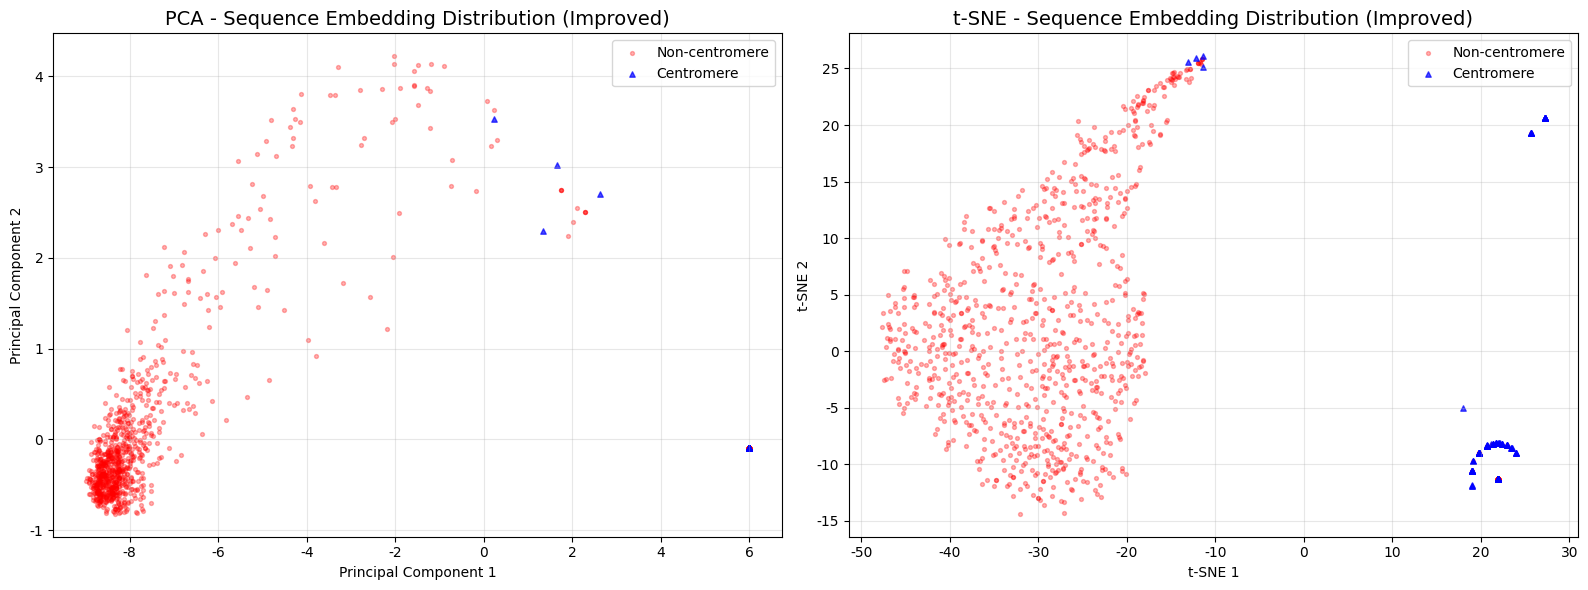

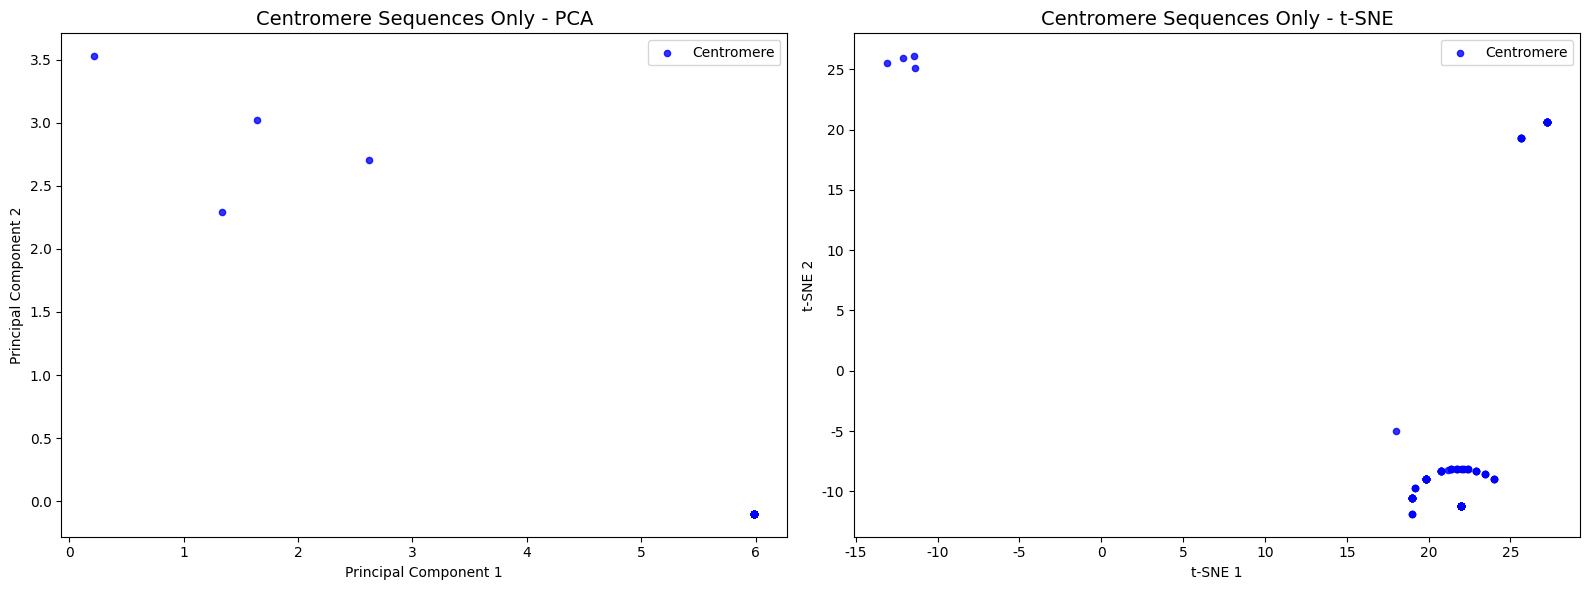

In [ ]:
# 改进的可视化函数 - 解决重叠问题
def improved_visualization(results):
    """改进的可视化，解决点重叠问题"""
    labels = results['labels']
    pca_data = results['pca']
    tsne_data = results['tsne']

    # 创建子图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. PCA图 - 使用不同的标记和透明度
    centromere_mask = labels == 1
    non_centromere_mask = labels == 0

    # 对蓝色点（着丝粒）使用更大的标记和更低的透明度
    ax1.scatter(pca_data[non_centromere_mask, 0], pca_data[non_centromere_mask, 1],
               alpha=0.3, s=8, c='red', label='Non-centromere', marker='o')
    ax1.scatter(pca_data[centromere_mask, 0], pca_data[centromere_mask, 1],
               alpha=0.7, s=15, c='blue', label='Centromere', marker='^')  # 使用三角形标记

    ax1.set_title('PCA - Sequence Embedding Distribution (Improved)', fontsize=14)
    ax1.legend()
    ax1.set_xlabel('Principal Component 1')
    ax1.set_ylabel('Principal Component 2')
    ax1.grid(True, alpha=0.3)

    # 2. t-SNE图 - 同样改进
    ax2.scatter(tsne_data[non_centromere_mask, 0], tsne_data[non_centromere_mask, 1],
               alpha=0.3, s=8, c='red', label='Non-centromere', marker='o')
    ax2.scatter(tsne_data[centromere_mask, 0], tsne_data[centromere_mask, 1],
               alpha=0.7, s=15, c='blue', label='Centromere', marker='^')

    ax2.set_title('t-SNE - Sequence Embedding Distribution (Improved)', fontsize=14)
    ax2.legend()
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 额外：单独显示着丝粒点的分布
    if np.sum(centromere_mask) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        ax1.scatter(pca_data[centromere_mask, 0], pca_data[centromere_mask, 1],
                   alpha=0.8, s=20, c='blue', label='Centromere')
        ax1.set_title('Centromere Sequences Only - PCA', fontsize=14)
        ax1.legend()
        ax1.set_xlabel('Principal Component 1')
        ax1.set_ylabel('Principal Component 2')

        ax2.scatter(tsne_data[centromere_mask, 0], tsne_data[centromere_mask, 1],
                   alpha=0.8, s=20, c='blue', label='Centromere')
        ax2.set_title('Centromere Sequences Only - t-SNE', fontsize=14)
        ax2.legend()
        ax2.set_xlabel('t-SNE 1')
        ax2.set_ylabel('t-SNE 2')

        plt.tight_layout()
        plt.show()

print("生成改进的可视化...")
improved_visualization(results)

In [ ]:
# 检查采样过程
def check_sampling_bias(original_labels, sampled_labels):
    """检查采样是否有偏差"""
    original_positive_ratio = np.sum(original_labels == 1) / len(original_labels)
    sampled_positive_ratio = np.sum(sampled_labels == 1) / len(sampled_labels)

    print("=== Sampling Bias Check ===")
    print(f"Original positive sample ratio: {original_positive_ratio:.2%}")
    print(f"Sampled positive sample ratio: {sampled_positive_ratio:.2%}")
    print(f"Bias: {abs(original_positive_ratio - sampled_positive_ratio):.2%}")

    if abs(original_positive_ratio - sampled_positive_ratio) > 0.05:
        print("⚠️ Significant sampling bias detected")
        return True
    else:
        print("✅ Sampling ratio maintained")
        return False

# 重新加载数据来检查采样偏差
try:
    data_path = "/content/drive/MyDrive/cen_dna/centromere_dataset_balanced_clean.csv"
    df = pd.read_csv(data_path)
    all_labels = df['label'].values

    # 检查采样偏差
    has_bias = check_sampling_bias(all_labels[:5000], results['labels'])
except Exception as e:
    print(f"无法检查采样偏差: {e}")
    print("继续使用当前结果进行分析")

=== Sampling Bias Check ===
Original positive sample ratio: 51.42%
Sampled positive sample ratio: 49.00%
Bias: 2.42%
✅ Sampling ratio maintained


分析数据分布特性...
=== Distribution Characteristics Analysis ===
Centromere sequences distribution in PCA space:
  X-axis: 0.22 to 5.99
  Y-axis: -0.10 to 3.53

Centromere sequences distribution in t-SNE space:
  X-axis: -13.09 to 27.23
  Y-axis: -11.87 to 26.09


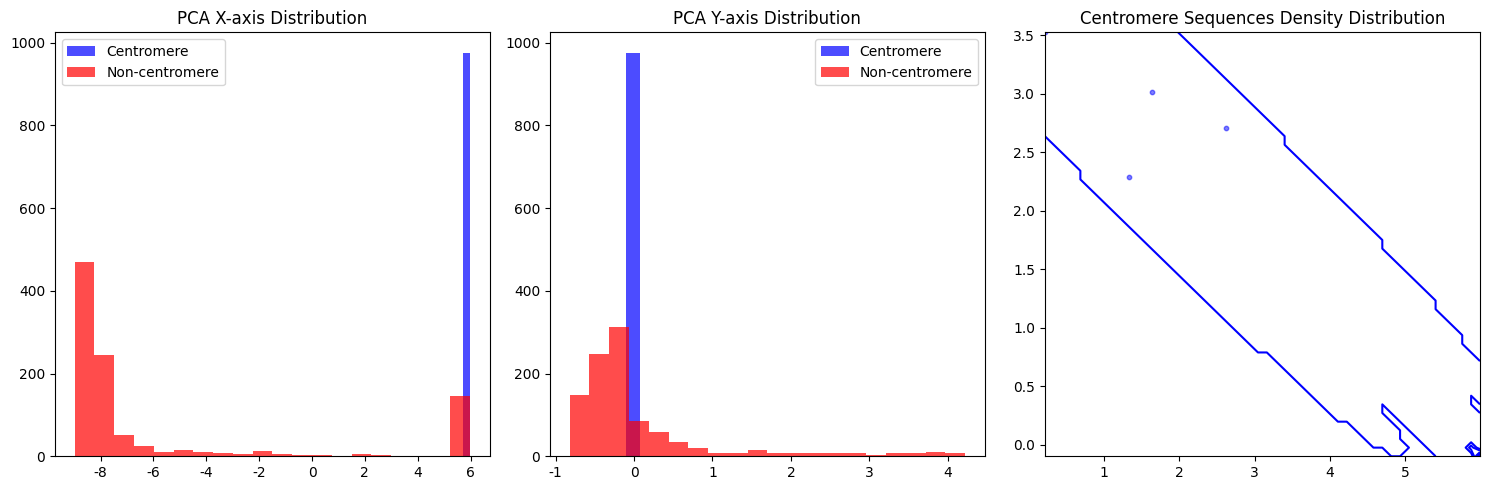

In [ ]:
# 深入分析数据分布特性
def analyze_distribution_characteristics(results):
    """分析数据分布特性"""
    labels = results['labels']
    embeddings = results['embeddings']

    centromere_embeddings = embeddings[labels == 1]
    non_centromere_embeddings = embeddings[labels == 0]

    print("=== Distribution Characteristics Analysis ===")

    # 检查是否有着丝粒序列聚集在特定区域
    centromere_pca = results['pca'][labels == 1]
    centromere_tsne = results['tsne'][labels == 1]

    if len(centromere_pca) > 0:
        print(f"Centromere sequences distribution in PCA space:")
        print(f"  X-axis: {centromere_pca[:, 0].min():.2f} to {centromere_pca[:, 0].max():.2f}")
        print(f"  Y-axis: {centromere_pca[:, 1].min():.2f} to {centromere_pca[:, 1].max():.2f}")

        print(f"\nCentromere sequences distribution in t-SNE space:")
        print(f"  X-axis: {centromere_tsne[:, 0].min():.2f} to {centromere_tsne[:, 0].max():.2f}")
        print(f"  Y-axis: {centromere_tsne[:, 1].min():.2f} to {centromere_tsne[:, 1].max():.2f}")

        # 可视化分布密度
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.hist(centromere_pca[:, 0], bins=20, alpha=0.7, color='blue', label='Centromere')
        plt.hist(results['pca'][labels == 0, 0], bins=20, alpha=0.7, color='red', label='Non-centromere')
        plt.title('PCA X-axis Distribution')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.hist(centromere_pca[:, 1], bins=20, alpha=0.7, color='blue', label='Centromere')
        plt.hist(results['pca'][labels == 0, 1], bins=20, alpha=0.7, color='red', label='Non-centromere')
        plt.title('PCA Y-axis Distribution')
        plt.legend()

        plt.subplot(1, 3, 3)
        # 散点图密度版本
        if len(centromere_pca) > 1:
            kde = gaussian_kde(centromere_pca.T)
            x_range = np.linspace(centromere_pca[:, 0].min(), centromere_pca[:, 0].max(), 50)
            y_range = np.linspace(centromere_pca[:, 1].min(), centromere_pca[:, 1].max(), 50)
            X, Y = np.meshgrid(x_range, y_range)
            positions = np.vstack([X.ravel(), Y.ravel()])
            Z = kde(positions).reshape(X.shape)

            plt.contour(X, Y, Z, levels=5, colors='blue')
            plt.scatter(centromere_pca[:, 0], centromere_pca[:, 1], alpha=0.5, s=10, c='blue')
            plt.title('Centromere Sequences Density Distribution')

        plt.tight_layout()
        plt.show()
    else:
        print("No centromere sequences found in the sample")

print("分析数据分布特性...")
analyze_distribution_characteristics(results)

# CENPB-box


In [ ]:
# 安装Biopython
!pip install biopython

import re
from Bio import SeqIO
from Bio.Seq import Seq


# CENPA-centromere DNA interaction